---
Phase 4-CV-2: 經典 CNN 架構演進 — LeNet → AlexNet → VGG → ResNet
---

深度學習的歷史，就是 CNN 架構演進的歷史。
每一代都解決了前一代的痛點。

本檔涵蓋：
  1. LeNet-5 (1998) — 手寫數字辨識的起點
  2. AlexNet (2012) — 深度學習的文藝復興
  3. VGG (2014) — 更深更規則
  4. ResNet (2015) — 殘差連接解決梯度消失
  5. 架構演進比較

In [1]:
import warnings; warnings.filterwarnings("ignore")
%matplotlib inline
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# 1. LeNet-5 (Yann LeCun, 1998)
# ============================================================================

In [2]:
print("=" * 60)
print("1. LeNet-5 — CNN 的開山祖師")
print("=" * 60)

print("""
LeNet-5 是第一個成功的 CNN，用在郵局手寫郵遞區號辨識。

架構：
  Input (1×32×32)
  → Conv(6, 5×5) → AvgPool(2)     → (6×14×14)
  → Conv(16, 5×5) → AvgPool(2)    → (16×5×5)
  → Flatten → FC(120) → FC(84) → FC(10)

特點：
  - 很小（~60K 參數）
  - 用 Average Pooling（當時 Max Pooling 還沒流行）
  - 用 Tanh 而非 ReLU
""")


class LeNet5(nn.Module):
    """LeNet-5 (現代版, 用 ReLU + MaxPool)"""
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, 5),           # (1,32,32) → (6,28,28)
            nn.ReLU(),
            nn.MaxPool2d(2),               # → (6,14,14)
            nn.Conv2d(6, 16, 5),          # → (16,10,10)
            nn.ReLU(),
            nn.MaxPool2d(2),               # → (16,5,5)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 5 * 5, 120),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = LeNet5()
x = torch.randn(1, 1, 32, 32)
print(f"LeNet-5 輸出: {model(x).shape}")
print(f"參數量: {sum(p.numel() for p in model.parameters()):,}")

1. LeNet-5 — CNN 的開山祖師

LeNet-5 是第一個成功的 CNN，用在郵局手寫郵遞區號辨識。

架構：
  Input (1×32×32)
  → Conv(6, 5×5) → AvgPool(2)     → (6×14×14)
  → Conv(16, 5×5) → AvgPool(2)    → (16×5×5)
  → Flatten → FC(120) → FC(84) → FC(10)

特點：
  - 很小（~60K 參數）
  - 用 Average Pooling（當時 Max Pooling 還沒流行）
  - 用 Tanh 而非 ReLU

LeNet-5 輸出: torch.Size([1, 10])
參數量: 61,706


## 2. AlexNet (Krizhevsky, 2012)

In [3]:
print("\n" + "=" * 60)
print("2. AlexNet — ImageNet 冠軍，深度學習爆發的起點")
print("=" * 60)

print("""
AlexNet 在 2012 ImageNet 比賽中大勝傳統方法，震驚學術界。

關鍵創新：
  1. ReLU 取代 Sigmoid/Tanh（訓練快 6 倍）
  2. Dropout（防止過擬合）
  3. Data Augmentation（翻轉、裁剪、色彩抖動）
  4. 用 GPU 訓練（2 張 GTX 580）
  5. Local Response Normalization（後來被 BatchNorm 取代）

架構（簡化版）：
  Input (3×224×224)
  → Conv(96, 11×11, stride=4) → MaxPool → (96×27×27)
  → Conv(256, 5×5, pad=2) → MaxPool    → (256×13×13)
  → Conv(384, 3×3, pad=1)               → (384×13×13)
  → Conv(384, 3×3, pad=1)               → (384×13×13)
  → Conv(256, 3×3, pad=1) → MaxPool    → (256×6×6)
  → FC(4096) → FC(4096) → FC(1000)
""")


class AlexNet(nn.Module):
    """簡化版 AlexNet"""
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 11, stride=4, padding=2),  # (3,224,224)→(64,55,55)
            nn.ReLU(),
            nn.MaxPool2d(3, stride=2),                    # → (64,27,27)
            nn.Conv2d(64, 192, 5, padding=2),             # → (192,27,27)
            nn.ReLU(),
            nn.MaxPool2d(3, stride=2),                    # → (192,13,13)
            nn.Conv2d(192, 384, 3, padding=1),            # → (384,13,13)
            nn.ReLU(),
            nn.Conv2d(384, 256, 3, padding=1),            # → (256,13,13)
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),            # → (256,13,13)
            nn.ReLU(),
            nn.MaxPool2d(3, stride=2),                    # → (256,6,6)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = AlexNet()
x = torch.randn(1, 3, 224, 224)
print(f"AlexNet 輸出: {model(x).shape}")
print(f"參數量: {sum(p.numel() for p in model.parameters()):,}")
print(f"→ 大部分參數在 FC 層！(256×6×6=9216 → 4096 就要 ~37M 參數)")


2. AlexNet — ImageNet 冠軍，深度學習爆發的起點

AlexNet 在 2012 ImageNet 比賽中大勝傳統方法，震驚學術界。

關鍵創新：
  1. ReLU 取代 Sigmoid/Tanh（訓練快 6 倍）
  2. Dropout（防止過擬合）
  3. Data Augmentation（翻轉、裁剪、色彩抖動）
  4. 用 GPU 訓練（2 張 GTX 580）
  5. Local Response Normalization（後來被 BatchNorm 取代）

架構（簡化版）：
  Input (3×224×224)
  → Conv(96, 11×11, stride=4) → MaxPool → (96×27×27)
  → Conv(256, 5×5, pad=2) → MaxPool    → (256×13×13)
  → Conv(384, 3×3, pad=1)               → (384×13×13)
  → Conv(384, 3×3, pad=1)               → (384×13×13)
  → Conv(256, 3×3, pad=1) → MaxPool    → (256×6×6)
  → FC(4096) → FC(4096) → FC(1000)



AlexNet 輸出: torch.Size([1, 10])
參數量: 57,044,810
→ 大部分參數在 FC 層！(256×6×6=9216 → 4096 就要 ~37M 參數)


## 3. VGGNet (Simonyan & Zisserman, 2014)

In [4]:
print("\n" + "=" * 60)
print("3. VGG — 更深、更規則的設計哲學")
print("=" * 60)

print("""
VGG 的設計哲學：
  只用 3×3 卷積 + 2×2 MaxPool
  重複堆疊，逐漸加深

為什麼用 3×3 而不是更大的卷積核？
  兩層 3×3 = 一層 5×5 的感受野
  但參數更少：2 × (3×3) = 18 < 5×5 = 25
  而且多了一層非線性（多一個 ReLU）

VGG-16 架構：
  Block 1: 2 × Conv(64, 3×3) → Pool     (224→112)
  Block 2: 2 × Conv(128, 3×3) → Pool    (112→56)
  Block 3: 3 × Conv(256, 3×3) → Pool    (56→28)
  Block 4: 3 × Conv(512, 3×3) → Pool    (28→14)
  Block 5: 3 × Conv(512, 3×3) → Pool    (14→7)
  → FC(4096) → FC(4096) → FC(1000)
""")


def make_vgg_block(in_ch, out_ch, num_convs):
    """建立 VGG 的一個 block"""
    layers = []
    for i in range(num_convs):
        layers.append(nn.Conv2d(in_ch if i == 0 else out_ch, out_ch, 3, padding=1))
        layers.append(nn.ReLU())
    layers.append(nn.MaxPool2d(2, 2))
    return nn.Sequential(*layers)


class VGG16(nn.Module):
    """VGG-16"""
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            make_vgg_block(3, 64, 2),     # 224→112
            make_vgg_block(64, 128, 2),   # 112→56
            make_vgg_block(128, 256, 3),  # 56→28
            make_vgg_block(256, 512, 3),  # 28→14
            make_vgg_block(512, 512, 3),  # 14→7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = VGG16()
x = torch.randn(1, 3, 224, 224)
print(f"VGG-16 輸出: {model(x).shape}")
print(f"參數量: {sum(p.numel() for p in model.parameters()):,}")
print(f"→ ~138M 參數！大部分在 FC 層。很大但很有效。")


3. VGG — 更深、更規則的設計哲學

VGG 的設計哲學：
  只用 3×3 卷積 + 2×2 MaxPool
  重複堆疊，逐漸加深

為什麼用 3×3 而不是更大的卷積核？
  兩層 3×3 = 一層 5×5 的感受野
  但參數更少：2 × (3×3) = 18 < 5×5 = 25
  而且多了一層非線性（多一個 ReLU）

VGG-16 架構：
  Block 1: 2 × Conv(64, 3×3) → Pool     (224→112)
  Block 2: 2 × Conv(128, 3×3) → Pool    (112→56)
  Block 3: 3 × Conv(256, 3×3) → Pool    (56→28)
  Block 4: 3 × Conv(512, 3×3) → Pool    (28→14)
  Block 5: 3 × Conv(512, 3×3) → Pool    (14→7)
  → FC(4096) → FC(4096) → FC(1000)



VGG-16 輸出: torch.Size([1, 10])
參數量: 134,301,514
→ ~138M 參數！大部分在 FC 層。很大但很有效。


## 4. ResNet (He et al., 2015)

In [5]:
print("\n" + "=" * 60)
print("4. ResNet — 殘差連接，解決梯度消失")
print("=" * 60)

print("""
問題：網路越深越好嗎？
  VGG 到 19 層就到極限了
  更深的網路反而表現更差（不是過擬合！是訓練 loss 就更高）
  原因：梯度在反向傳播時逐層衰減 → 深層學不到東西

ResNet 的解法 — 殘差連接 (Skip Connection)：
  不學 F(x)，改學 F(x) + x
  也就是只學「殘差」= 和輸入的差異

  ┌─────────────────────┐
  │  x ───→ Conv → ReLU → Conv ──→ (+) ──→ ReLU → out
  │  │                              ↑
  │  └──────── shortcut ────────────┘
  │                              (identity)
  └─────────────────────┘

  為什麼有效？
  1. 梯度可以直接跳過層往回傳（shortcut 的梯度 = 1）
  2. 最差情況：F(x) = 0，那就是 identity → 至少不會更差
  3. 讓網路可以到 100+ 層、甚至 1000+ 層！
""")


class ResidualBlock(nn.Module):
    """基本殘差塊"""
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x                         # 保存輸入
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + residual                  # 加上 shortcut！
        return F.relu(out)


class ResidualBlockDown(nn.Module):
    """帶降維的殘差塊（通道數改變或尺寸改變時用）"""
    def __init__(self, in_ch, out_ch, stride=2):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_ch)
        # shortcut 也要調整維度
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, stride=stride),
            nn.BatchNorm2d(out_ch),
        )

    def forward(self, x):
        residual = self.shortcut(x)
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + residual
        return F.relu(out)


class SimpleResNet(nn.Module):
    """簡化版 ResNet（用於 MNIST/CIFAR 小圖片）"""
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        self.layer1 = nn.Sequential(
            ResidualBlock(16),
            ResidualBlock(16),
        )
        self.layer2 = nn.Sequential(
            ResidualBlockDown(16, 32),
            ResidualBlock(32),
        )
        self.layer3 = nn.Sequential(
            ResidualBlockDown(32, 64),
            ResidualBlock(64),
        )

        self.pool = nn.AdaptiveAvgPool2d(1)  # 全局平均池化
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x)              # (B, 64, 1, 1)
        x = x.view(x.size(0), -1)     # (B, 64)
        return self.fc(x)


model = SimpleResNet()
x = torch.randn(1, 1, 28, 28)
print(f"SimpleResNet 輸出: {model(x).shape}")
print(f"參數量: {sum(p.numel() for p in model.parameters()):,}")

# 展示殘差連接的效果
print("\n--- 殘差連接 vs 無殘差 ---")
print("用簡單的數值實驗來感受差異：")

torch.manual_seed(42)
x = torch.randn(4, 16, 8, 8)

# 有殘差的 block
res_block = ResidualBlock(16)
res_block.eval()
with torch.no_grad():
    out_res = res_block(x)

# 模擬無殘差（只做 conv→bn→relu→conv→bn→relu）
with torch.no_grad():
    out_no_res = F.relu(res_block.bn1(res_block.conv1(x)))
    out_no_res = F.relu(res_block.bn2(res_block.conv2(out_no_res)))

print(f"  輸入 x 的 mean: {x.mean():.4f}, std: {x.std():.4f}")
print(f"  有殘差的輸出 mean: {out_res.mean():.4f}, std: {out_res.std():.4f}")
print(f"  無殘差的輸出 mean: {out_no_res.mean():.4f}, std: {out_no_res.std():.4f}")
print(f"  → 殘差連接讓信號更穩定地傳播")


4. ResNet — 殘差連接，解決梯度消失

問題：網路越深越好嗎？
  VGG 到 19 層就到極限了
  更深的網路反而表現更差（不是過擬合！是訓練 loss 就更高）
  原因：梯度在反向傳播時逐層衰減 → 深層學不到東西

ResNet 的解法 — 殘差連接 (Skip Connection)：
  不學 F(x)，改學 F(x) + x
  也就是只學「殘差」= 和輸入的差異

  ┌─────────────────────┐
  │  x ───→ Conv → ReLU → Conv ──→ (+) ──→ ReLU → out
  │  │                              ↑
  │  └──────── shortcut ────────────┘
  │                              (identity)
  └─────────────────────┘

  為什麼有效？
  1. 梯度可以直接跳過層往回傳（shortcut 的梯度 = 1）
  2. 最差情況：F(x) = 0，那就是 identity → 至少不會更差
  3. 讓網路可以到 100+ 層、甚至 1000+ 層！

SimpleResNet 輸出: torch.Size([1, 10])
參數量: 175,530

--- 殘差連接 vs 無殘差 ---
用簡單的數值實驗來感受差異：
  輸入 x 的 mean: -0.0011, std: 0.9961
  有殘差的輸出 mean: 0.4053, std: 0.5897
  無殘差的輸出 mean: 0.0806, std: 0.1201
  → 殘差連接讓信號更穩定地傳播


## 5. 在 Digits 上比較不同架構


5. 架構比較實驗（在 sklearn Digits 上）



          Model:   Test Acc,     Params
---------------------------------------------


  MLP            : Test Acc=97.50%, Params=17,226


  CNN            : Test Acc=98.89%, Params=13,706


  ResNet         : Test Acc=99.17%, Params=38,474


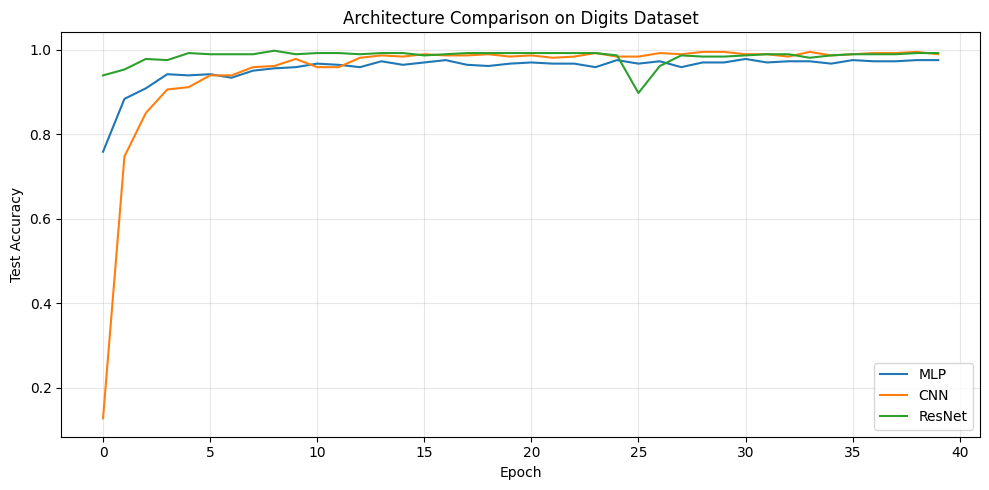


→ 圖表儲存至 cv/plots/02_architecture_comparison.png


In [6]:
print("\n" + "=" * 60)
print("5. 架構比較實驗（在 sklearn Digits 上）")
print("=" * 60)

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

digits = load_digits()
X = digits.data.reshape(-1, 1, 8, 8).astype(np.float32) / 16.0
y = digits.target.astype(np.int64)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

X_tr_t = torch.tensor(X_tr)
y_tr_t = torch.tensor(y_tr)
X_te_t = torch.tensor(X_te)
y_te_t = torch.tensor(y_te)
train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 簡單的 MLP 作為 baseline
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 10),
        )
    def forward(self, x):
        return self.net(x)

# 簡單 CNN
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(32 * 2 * 2, 64), nn.ReLU(), nn.Linear(64, 10),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

# 小 ResNet
class TinyResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.res1 = ResidualBlock(16)
        self.down = ResidualBlockDown(16, 32)
        self.res2 = ResidualBlock(32)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(32, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.res1(x)
        x = self.down(x)
        x = self.res2(x)
        x = self.pool(x).view(x.size(0), -1)
        return self.fc(x)


def train_model(model, name, epochs=40):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    history = []

    for epoch in range(epochs):
        model.train()
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            loss = criterion(model(bx), by)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            te_acc = (model(X_te_t.to(device)).argmax(1) == y_te_t.to(device)).float().mean().item()
            history.append(te_acc)

    params = sum(p.numel() for p in model.parameters())
    print(f"  {name:15s}: Test Acc={te_acc:.2%}, Params={params:,}")
    return history


print(f"\n{'Model':>15s}: {'Test Acc':>10s}, {'Params':>10s}")
print("-" * 45)

histories = {}
for name, model_cls in [('MLP', MLP), ('CNN', TinyCNN), ('ResNet', TinyResNet)]:
    torch.manual_seed(42)
    histories[name] = train_model(model_cls(), name)

# 畫學習曲線比較
fig, ax = plt.subplots(figsize=(10, 5))
for name, hist in histories.items():
    ax.plot(hist, label=name)
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy')
ax.set_title('Architecture Comparison on Digits Dataset')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('phase-4-domains/cv/plots/02_architecture_comparison.png', dpi=100)
plt.show()
print("\n→ 圖表儲存至 cv/plots/02_architecture_comparison.png")

## 6. 架構演進總覽

In [7]:
print("\n" + "=" * 60)
print("6. 架構演進總覽")
print("=" * 60)

print("""
  年份    架構       深度    參數量     Top-5 Error   關鍵創新
  ────────────────────────────────────────────────────────────
  1998   LeNet-5     5      60K       N/A          CNN 的起源
  2012   AlexNet     8      62M       16.4%        ReLU + GPU + Dropout
  2014   VGG-16     16     138M       7.3%         3×3 卷積堆疊
  2014   GoogLeNet  22       7M       6.7%         Inception module
  2015   ResNet-152 152     60M       3.6%         殘差連接
  2017   SENet       -       -        2.3%         通道注意力
  2019   EfficientNet  -     -        ~2%          NAS + 複合縮放

  趨勢：
  1. 越來越深（5→152 層）
  2. 殘差連接是里程碑
  3. 最終被 Vision Transformer (ViT) 超越
  4. 但 CNN 在邊緣裝置上仍然有速度優勢

  現代實務：
  - 小任務：用 ResNet-18/34 或 EfficientNet-B0
  - 大任務：用 pretrained model + fine-tune
  - 最新：Vision Transformer (ViT, Swin Transformer)

下一步：03_transfer_learning.py — 遷移學習
""")


6. 架構演進總覽

  年份    架構       深度    參數量     Top-5 Error   關鍵創新
  ────────────────────────────────────────────────────────────
  1998   LeNet-5     5      60K       N/A          CNN 的起源
  2012   AlexNet     8      62M       16.4%        ReLU + GPU + Dropout
  2014   VGG-16     16     138M       7.3%         3×3 卷積堆疊
  2014   GoogLeNet  22       7M       6.7%         Inception module
  2015   ResNet-152 152     60M       3.6%         殘差連接
  2017   SENet       -       -        2.3%         通道注意力
  2019   EfficientNet  -     -        ~2%          NAS + 複合縮放

  趨勢：
  1. 越來越深（5→152 層）
  2. 殘差連接是里程碑
  3. 最終被 Vision Transformer (ViT) 超越
  4. 但 CNN 在邊緣裝置上仍然有速度優勢

  現代實務：
  - 小任務：用 ResNet-18/34 或 EfficientNet-B0
  - 大任務：用 pretrained model + fine-tune
  - 最新：Vision Transformer (ViT, Swin Transformer)

下一步：03_transfer_learning.py — 遷移學習

